# Hospital Readmission Prediction

**Objective:**  
Build a baseline machine learning model to predict whether a patient will be readmitted to the hospital using demographic, clinical, and visit-related features.

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_score, recall_score
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingClassifier

In [2]:
# Load dataset
raw_dir = "../data/raw"
csv_path = os.path.join(raw_dir, [f for f in os.listdir(raw_dir) if f.endswith(".csv")][0])

df = pd.read_csv(csv_path)

# Create target variable
df["readmitted_flag"] = df["readmitted"].map({"no": 0, "yes": 1})

df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted,readmitted_flag
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no,0
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no,0
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes,1
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes,1
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no,0


In [3]:
y = df["readmitted_flag"]
x = df.drop(columns = ["readmitted", "readmitted_flag"])

In [4]:
num_cols = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = x.select_dtypes(include=["object"]).columns.tolist()

In [5]:
# Preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("log_reg", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# Fit model
model.fit(x_train, y_train)

# Predictions
pred = model.predict(x_test)
proba = model.predict_proba(x_test)[:, 1]

# Results
print(classification_report(y_test, pred))
print("ROC AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.62      0.71      0.66      2649
           1       0.60      0.50      0.55      2351

    accuracy                           0.61      5000
   macro avg       0.61      0.61      0.60      5000
weighted avg       0.61      0.61      0.61      5000

ROC AUC: 0.6450720390943896


### Handling Class Imbalance

Because hospital readmissions are less frequent than non-readmissions, the dataset is slightly imbalanced.
To address this, the logistic regression model was trained using class-weight balancing.

This approach increases the importance of readmitted cases during training and helps improve recall for the positive class.


## Model Interpretation

The baseline logistic regression model achieves a ROC AUC of approximately 0.64.  
This result provides a reasonable benchmark and highlights the difficulty of predicting hospital readmissions using tabular clinical data.


### Baseline Model Results

The logistic regression baseline achieves a ROC AUC of approximately 0.65, indicating moderate ability to distinguish between patients who are readmitted and those who are not.  

Recall for the readmitted class is lower than for the non readmitted class, which suggests the model struggles to capture all readmission cases. This is expected for a simple baseline and motivates further model improvements.


### Class Balance

The target variable is slightly imbalanced, with fewer readmission cases than non readmission cases. Stratified sampling was used during train test split to preserve the class distribution.


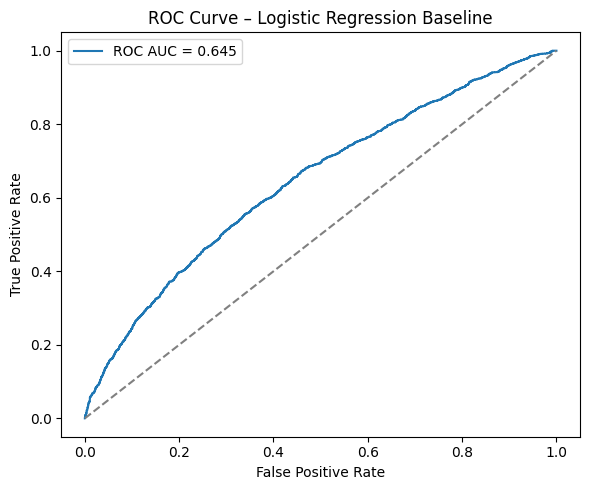

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, proba):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Extract feature names after preprocessing
feature_names = model.named_steps["preprocess"].get_feature_names_out()

coefficients = model.named_steps["log_reg"].coef_[0]

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefficients
    })
    .sort_values(by="coefficient", key=abs, ascending=False)
)

importance_df.head(15)


,feature,coefficient
40,cat__diag_3_Missing,-0.584121
5,num__n_inpatient,0.382280
6,num__n_emergency,0.249278
21,cat__diag_1_Diabetes,0.246074
24,cat__diag_1_Missing,-0.228418
52,cat__diabetes_med_no,-0.223563
12,cat__age_[90-100),-0.214449
32,cat__diag_2_Missing,0.209736
19,cat__medical_specialty_Surgery,-0.206360
49,cat__A1Ctest_normal,-0.179327


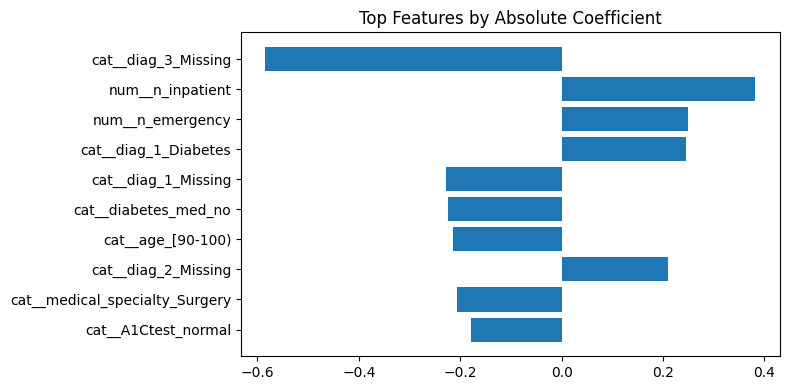

In [8]:
top_features = importance_df.head(10)

plt.figure(figsize=(8, 4))
plt.barh(top_features["feature"], top_features["coefficient"])
plt.title("Top Features by Absolute Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Feature Interpretation

Logistic regression coefficients provide insight into which clinical and visit-related features
are most strongly associated with hospital readmission risk.

These results improve model transparency and help connect predictions to real-world clinical factors.


## Improved Model: Gradient Boosting

In [9]:
gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gb", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(x_train, y_train)

gb_pred = gb_model.predict(x_test)
gb_proba = gb_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_proba))

              precision    recall  f1-score   support

           0       0.62      0.75      0.68      2649
           1       0.63      0.47      0.54      2351

    accuracy                           0.62      5000
   macro avg       0.62      0.61      0.61      5000
weighted avg       0.62      0.62      0.61      5000

ROC AUC: 0.6572977066215528


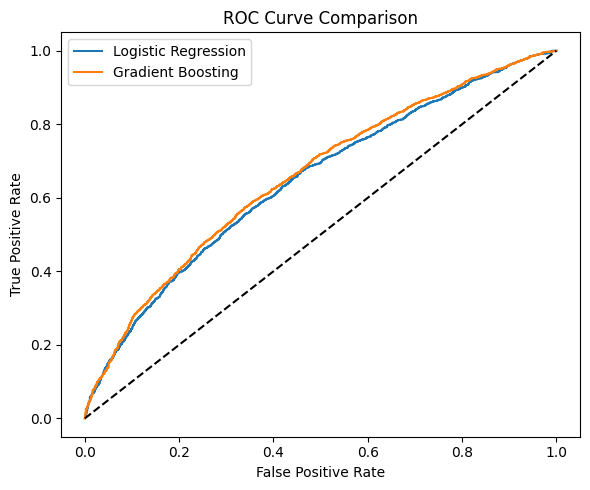

In [10]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
risk_df = pd.DataFrame({
    "true_label": y_test.values,
    "predicted_risk": gb_proba
})

risk_df["risk_bucket"] = pd.qcut(
    risk_df["predicted_risk"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

risk_df.groupby("risk_bucket")["true_label"].mean()

/var/folders/t_/t28x_hf50bzf4yjwfmmf65s80000gn/T/ipykernel_77365/1503786954.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_df.groupby("risk_bucket")["true_label"].mean()


risk_bucket
Very Low     0.302
Low          0.365
Medium       0.463
High         0.529
Very High    0.692
Name: true_label, dtype: float64

In [13]:
thresholds = np.arange(0.1, 0.9, 0.1)

results = []

for t in thresholds:
    preds = (gb_proba >= t).astype(int)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    
    results.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "patients_flagged_%": preds.mean() * 100
    })
    
threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,patients_flagged_%
0,0.1,0.470200,1.000000,100.00
1,0.2,0.470565,0.999575,99.88
2,0.3,0.481668,0.977882,95.46
3,0.4,0.547810,0.755423,64.84
4,0.5,0.627907,0.470863,35.26
5,0.6,0.704762,0.251808,16.80
6,0.7,0.747826,0.109741,6.90
7,0.8,0.828571,0.037006,2.10


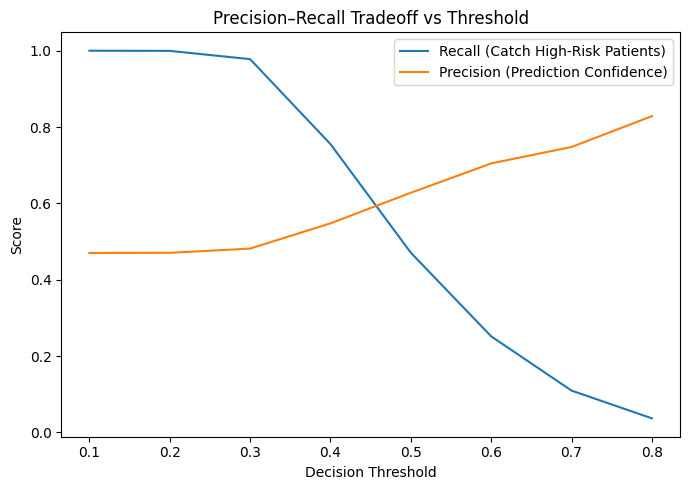

In [14]:
plt.figure(figsize=(7,5))
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall (Catch High-Risk Patients)")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision (Prediction Confidence)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Tradeoff vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

## Practical Hospital Impact Simulation

Instead of focusing only on model accuracy, we evaluate how this system would perform in a real hospital setting. Since hospitals have limited staff and resources, we simulate an intervention strategy where only the top 20% highest-risk patients receive additional care.

This approach allows us to measure how effectively the model can prioritize patients and support clinical decision-making under real-world constraints.


In [19]:
# Simulate intervention capacity: top 20% highest risk patients

top_pct = 0.20
cutoff = np.quantile(gb_proba, 1 - top_pct)

intervention_preds = (gb_proba >= cutoff).astype(int)

precision_int = precision_score(y_test, intervention_preds)
recall_int = recall_score(y_test, intervention_preds)
coverage = intervention_preds.mean()

print("Readmission rate among top 20% highest-risk patients:", round(precision_int,3))
recall_int, coverage

Readmission rate among top 20% highest-risk patients: 0.692


(0.2943428328370906, np.float64(0.2))

In [20]:
# Economic impact simulation

avg_readmission_cost = 15000 #USD

prevented_readmissions = recall_int * y_test.sum()

estimated_savings = prevented_readmissions * avg_readmission_cost

prevented_readmissions, estimated_savings

(np.float64(692.0), np.float64(10380000.0))

In [23]:
print("\n--- Clinical and Economic Impact Simulation ---\n")

print(f" Hospital intervention capacity: Top {int(top_pct*100)}% highest-risk patients")

print(f" Precision among high-risk patients: {precision_int:.1%}")
print("   Of the patients flagged as high risk, this percentage were actually readmitted.\n")

print(f" Clinical coverage (recall): {recall_int:.1%}")
print("   Percentage of all readmitted patients that the model successfully identifies.\n")

print(f" Potential readmissions prevented: {int(prevented_readmissions)} patients")

print(f" Estimated cost savings: ${estimated_savings:,.0f} USD")

print("\n Interpretation:")
print("This simulation shows how machine learning can help hospitals prioritize high risk patients,")
print("improve patient outcomes, and generate substantial healthcare cost savings.")



--- Clinical and Economic Impact Simulation ---

 Hospital intervention capacity: Top 20% highest-risk patients
 Precision among high-risk patients: 69.2%
   Of the patients flagged as high risk, this percentage were actually readmitted.

 Clinical coverage (recall): 29.4%
   Percentage of all readmitted patients that the model successfully identifies.

 Potential readmissions prevented: 692 patients
 Estimated cost savings: $10,380,000 USD

 Interpretation:
This simulation shows how machine learning can help hospitals prioritize high risk patients,
improve patient outcomes, and generate substantial healthcare cost savings.
